In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# 1. Cargar el dataset
df = pd.read_csv('nba_10000_dirty.csv')
df.head()

,year,Season_type,PLAYER_ID,RANK,PLAYER,TEAM_ID,TEAM,GP,MIN,FGM,...,REB,AST,STL,BLK,TOV,PF,PTS,EFF,AST_TOV,STL_TOV
0,2020-21,Playoffs,203109.0,21.0,Jae Crowder,1.610613e+09,PHX,22.0,729.0,76.0,...,134.0,41.0,19.0,18.0,19.0,67.0,237.0,318.0,2.16,1.00
1,2018-19,Regular%20Season,1626210.0,481.0,Alan Williams,1.610613e+09,BKN,5.0,26.0,8.0,...,19.0,3.0,1.0,0.0,1.0,2.0,18.0,33.0,3.00,1.00
2,2014-15,Regular%20Season,202366.0,370.0,Jerome Jordan,1.610613e+09,BKN,44.0,383.0,50.0,...,105.0,13.0,8.0,15.0,22.0,58.0,138.0,207.0,0.59,0.36
3,2018-19,Playoffs,200768.0,9.0,Kyle Lowry,1.610613e+09,TOR,24.0,900.0,122.0,...,117.0,159.0,31.0,7.0,54.0,96.0,361.0,450.0,2.94,0.57
4,2018-19,Regular%20Season,2733.0,318.0,Shaun Livingston,1.610613e+09,GSW,64.0,967.0,109.0,...,117.0,114.0,31.0,27.0,38.0,74.0,258.0,397.0,3.00,0.82


In [3]:
# --- Nivel 1: Limpieza Básica (Duplicados y Nulos Críticos) ---

# 1. Contar cuántos duplicados hay
total_dupli = df.duplicated().sum()
print(f'Cantidad de registros duplicados: {total_dupli}')

# 2. Mostrar cuáles son antes de borrar
if total_dupli > 0:
    print('\nRegistros detectados como duplicados:')
    print(df[df.duplicated(keep=False)])

# 3. Eliminar duplicados de forma permanente usando .copy()
df_clean = df.drop_duplicates().copy()
print(f'\nLimpieza realizada. Nuevo total de filas: {len(df_clean)}\n')

# 4. Identifica cuántos datos nulos (NaN) hay por cada columna
nulos_por_columna = df_clean.isnull().sum()
print("Conteo de datos faltantes por columna:")
print(nulos_por_columna)

# Eliminamos valores nulos críticos (Jugador y Equipo)
df_clean = df_clean.dropna(subset=['PLAYER', 'TEAM']).copy()
print(f"\nFilas restantes después de eliminar nulos críticos: {len(df_clean)}")

Cantidad de registros duplicados: 500

Registros detectados como duplicados:
         year       Season_type  PLAYER_ID   RANK          PLAYER  \
14    2017-18          Playoffs  1628369.0    6.0    Jayson Tatum   
29    2013-14          Playoffs   202322.0   26.0       John Wall   
44    2015-16          Playoffs   201584.0   89.0    Courtney Lee   
45    2012-13  Regular%20Season     1495.0   40.0      Tim Duncan   
48    2014-15  Regular%20Season   203495.0  397.0      Ricky Ledo   
...       ...               ...        ...    ...             ...   
9957  2022-23  Regular%20Season   203082.0  220.0   Terrence Ross   
9961  2013-14  Regular%20Season   201942.0    8.0   DeMar DeRozan   
9972  2019-20  Regular%20Season  1629741.0  349.0   Marko Guduric   
9977  2018-19          Playoffs   202324.0   91.0  Derrick Favors   
9982  2013-14          Playoffs   202322.0   26.0       John Wall   

           TEAM_ID TEAM    GP     MIN    FGM  ...    REB    AST   STL    BLK  \
14    1.610613


--- Analizando Outliers en Puntos (PTS) ---


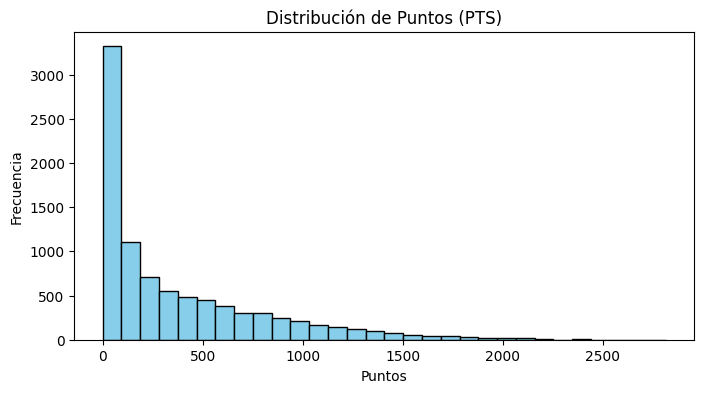


Registros detectados con puntos fuera de rango (Outliers): 154
                    PLAYER     PTS
24          Damian Lillard  1978.0
33   Giannis Antetokounmpo  1857.0
47      Karl-Anthony Towns  1743.0
66       Russell Westbrook  2558.0
121      LaMarcus Aldridge  1727.0

Limpieza de Outliers realizada. Total de filas limpias: 8768


In [4]:
# --- Nivel 3: Tratamiento de Outliers ---
print("\n--- Analizando Outliers en Puntos (PTS) ---")

# Visualización inicial
plt.figure(figsize=(8,4))
plt.hist(df_clean['PTS'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribución de Puntos (PTS)')
plt.xlabel('Puntos')
plt.ylabel('Frecuencia')
plt.show()

# Detectar y mostrar outliers (Z-Score >= 3)
z_scores = np.abs((df_clean['PTS'] - df_clean['PTS'].mean()) / df_clean['PTS'].std())
registros_con_error = df_clean[z_scores >= 3]

print(f"\nRegistros detectados con puntos fuera de rango (Outliers): {len(registros_con_error)}")
if len(registros_con_error) > 0:
    print(registros_con_error[['PLAYER', 'PTS']].head()) # Mostramos solo algunos para no saturar

# Limpieza: nos quedamos con los datos normales
df_clean = df_clean[z_scores < 3].copy()
print(f"\nLimpieza de Outliers realizada. Total de filas limpias: {len(df_clean)}")

In [5]:
# --- Creación de nuevas variables ---

# Evitamos divisiones por cero reemplazando los 0 en MIN por NaN temporalmente
df_clean['MIN'] = df_clean['MIN'].replace(0, np.nan)

# Aplicar cálculo vectorial (Feature Engineering)
df_clean['PTS_PER_MIN'] = df_clean['PTS'] / df_clean['MIN']
df_clean['PTS_PER_MIN'] = df_clean['PTS_PER_MIN'].fillna(0)

print("\nNueva columna 'PTS_PER_MIN' (Puntos por Minuto) calculada con éxito.")
print(df_clean[['PLAYER', 'PTS', 'MIN', 'PTS_PER_MIN']].head())


Nueva columna 'PTS_PER_MIN' (Puntos por Minuto) calculada con éxito.
             PLAYER    PTS    MIN  PTS_PER_MIN
0       Jae Crowder  237.0  729.0     0.325103
1     Alan Williams   18.0   26.0     0.692308
2     Jerome Jordan  138.0  383.0     0.360313
3        Kyle Lowry  361.0  900.0     0.401111
4  Shaun Livingston  258.0  967.0     0.266805



Matriz final transformada (Muestra de primeros registros):
[[-0.51382814 -0.10656857 -0.28325105 -0.33793349 -0.07430735 -0.06735554
   1.          0.        ]
 [-1.12246433 -0.99397603 -0.84761759 -0.69987771 -0.74925115  0.21043468
   0.          1.        ]
 [ 0.27381869 -0.54332957 -0.53837565 -0.60462923 -0.24451057 -0.04071887
   0.          1.        ]]


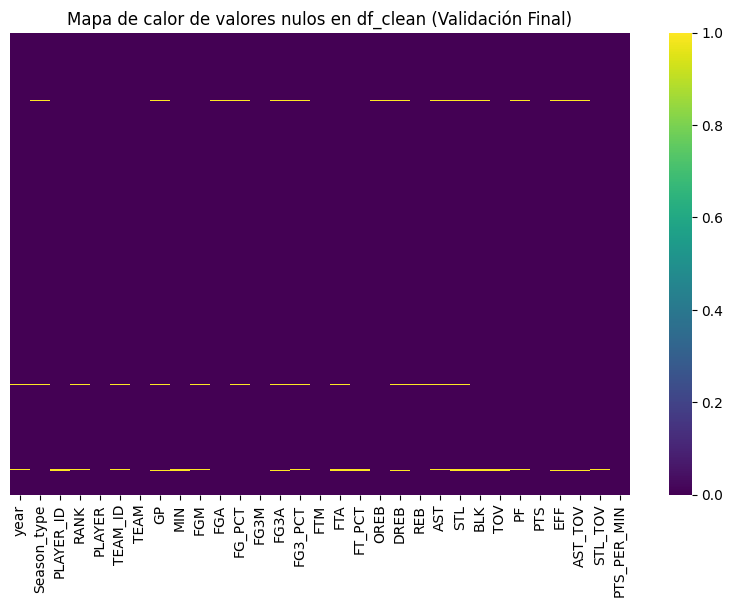

In [8]:
# --- Implementación en Pipeline o función reusable ---

numeric_features = ['GP', 'MIN', 'PTS', 'AST', 'REB', 'PTS_PER_MIN']
categorical_features = ['Season_type']

# Definimos el procesador numérico y categórico
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Creamos la tubería (ColumnTransformer)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Resultado: Una matriz lista para la IA
datos_listos = preprocessor.fit_transform(df_clean)
print("\nMatriz final transformada (Muestra de primeros registros):")
print(datos_listos[:3])

# --- Validación Final ---
plt.figure(figsize=(10,6))
sns.heatmap(df_clean.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Mapa de calor de valores nulos en df_clean (Validación Final)')
plt.show()

# Guardar el archivo limpio para GitHub
columnas_cat = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
columnas_finales = numeric_features + list(columnas_cat)
df_processed = pd.DataFrame(datos_listos, columns=columnas_finales)

df_processed.to_csv('nba_10000_processed.csv', index=False)